# Project 7 — Skin Cancer Detection

**Dataset:** HAM10000  
**Target:** >80% Melanoma Recall  
**Model:** EfficientNetV2-S (Transfer Learning, Fine-Tuned)

## 1. Environment Setup

### 1.1 Kaggle Authentication

In [1]:
!pip install -q kaggle
import os
from google.colab import files
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)

Saving kaggle.json to kaggle.json


### 1.2 Dataset Download

In [2]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip -q
print('Dataset ready.')

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
Dataset ready.


## 2. Imports & Configuration

In [10]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE  = 224
BATCH     = 32
EPOCHS    = 25
LR        = 3e-4
SEED      = 42
SAVE_PATH = 'skin_cancer_model.pth'

CLASS_NAMES = ['akiec','bcc','bkl','df','mel','nv','vasc']
LABEL_MAP   = {c: i for i, c in enumerate(CLASS_NAMES)}
MEL_IDX     = LABEL_MAP['mel']   # 4

torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


## 3. Data Loading & Preparation

### 3.1 Build DataFrame

In [11]:
BASE = Path('/content/ham10000')
csv_path = next(BASE.rglob('HAM10000_metadata.csv'))
df = pd.read_csv(csv_path)

img_lookup = {p.stem: p for p in BASE.rglob('*.jpg')}
df['path']  = df['image_id'].map(img_lookup)
df = df.dropna(subset=['path']).copy()
df['label'] = df['dx'].map(LABEL_MAP)

# De-duplicate: one image per lesion_id (keeps first occurrence)
df = df.drop_duplicates(subset='lesion_id', keep='first').reset_index(drop=True)

print(df['dx'].value_counts().to_string())
print(f'\nTotal images after dedup: {len(df)}')

dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73

Total images after dedup: 7470


## 4. Exploratory Data Analysis (EDA)

### 4.1 Class Distribution

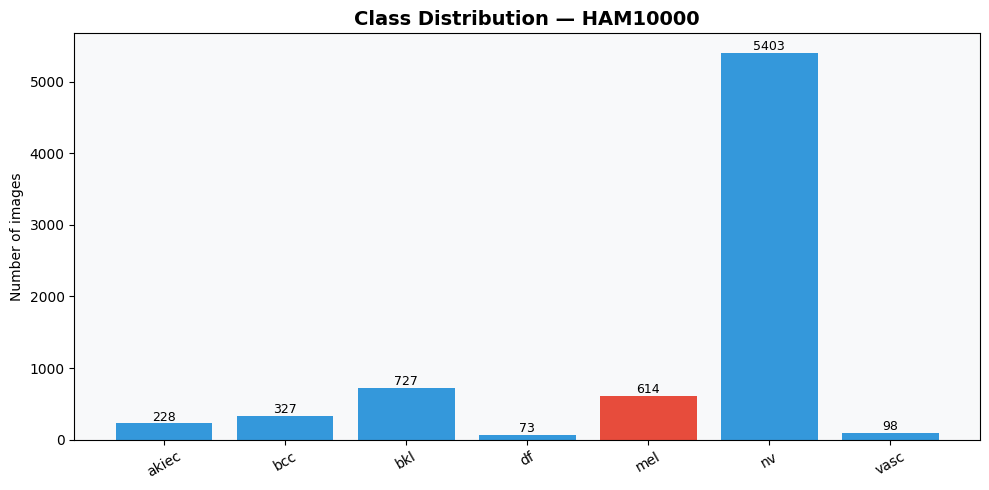

In [16]:
dist = df['dx'].value_counts().reindex(CLASS_NAMES, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c == 'mel' else '#3498db' for c in dist.index]
bars = ax.bar(dist.index, dist.values, color=colors)
ax.set_title('Class Distribution — HAM10000', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of images')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            str(int(bar.get_height())), ha='center', fontsize=9)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

### 4.2 Sample Images per Class

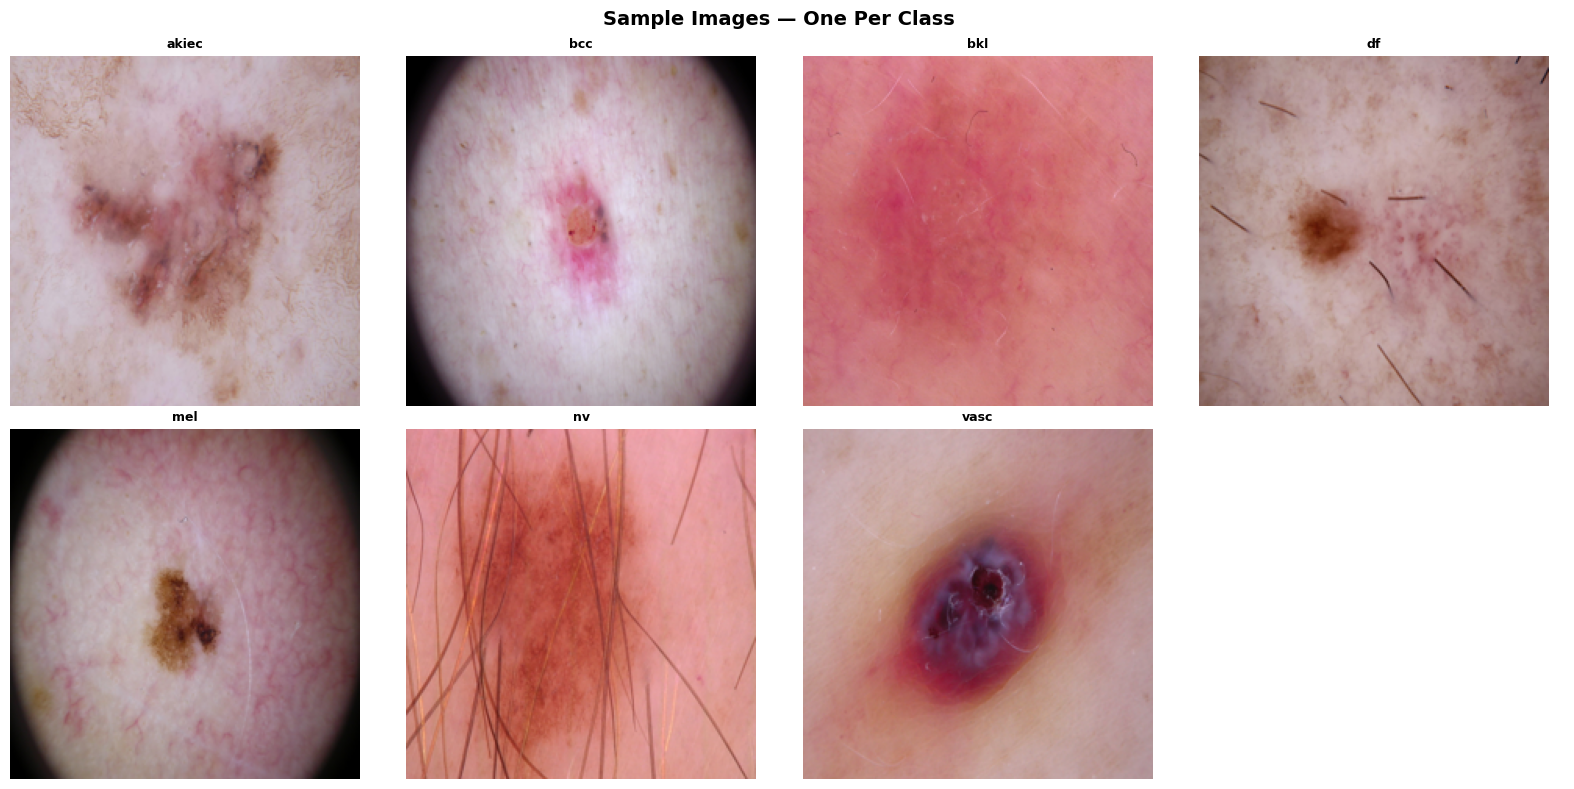

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cls_name in enumerate(CLASS_NAMES):
    sample_path = df[df['dx'] == cls_name]['path'].sample(1, random_state=7).values[0]
    img = Image.open(sample_path).resize((224, 224))
    axes[i].imshow(img)
    axes[i].set_title(f'{cls_name}', fontsize=9, fontweight='bold')
    axes[i].axis('off')

axes[7].axis('off')   # hide extra subplot
fig.suptitle('Sample Images — One Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Age Distribution by Class

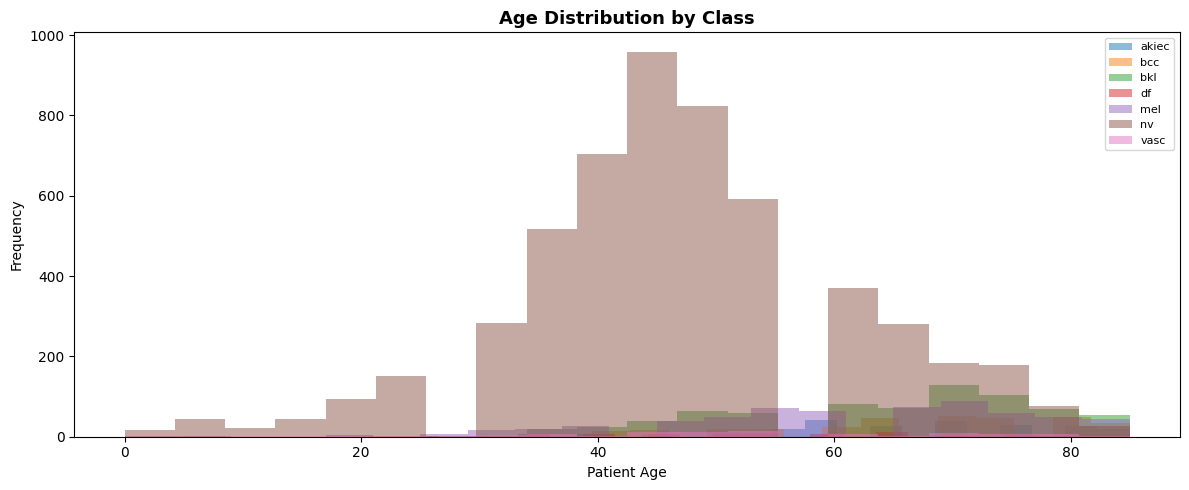

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
for cls_name in CLASS_NAMES:
    subset = df[df['dx'] == cls_name]['age'].dropna()
    ax.hist(subset, bins=20, alpha=0.5, label=cls_name)
ax.set_title('Age Distribution by Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Patient Age')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 4.4 Sex Distribution per Class

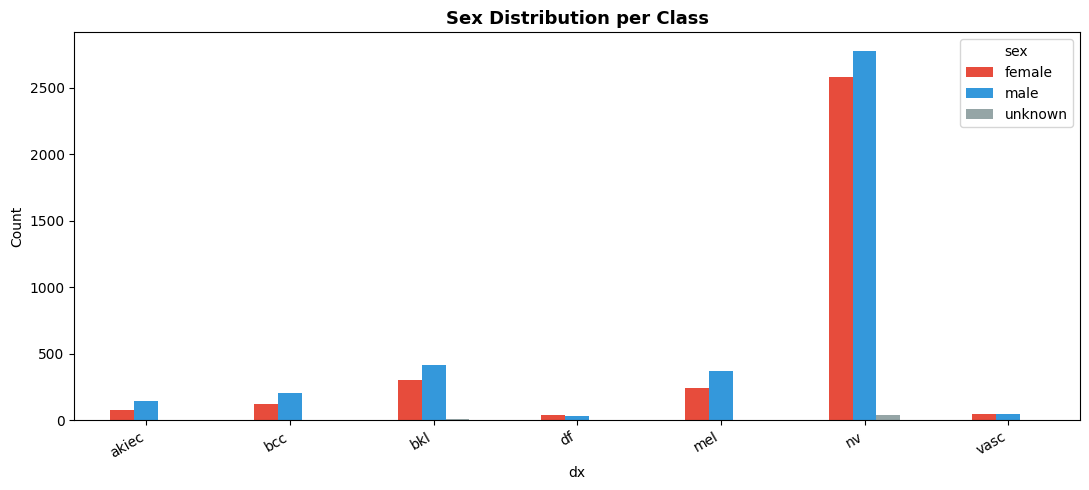

In [21]:
sex_pivot = df.groupby(['dx', 'sex']).size().unstack(fill_value=0)
sex_pivot.plot(kind='bar', figsize=(11, 5), color=['#e74c3c', '#3498db', '#95a5a6'])
plt.title('Sex Distribution per Class', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 4.5 Lesion Location by Class

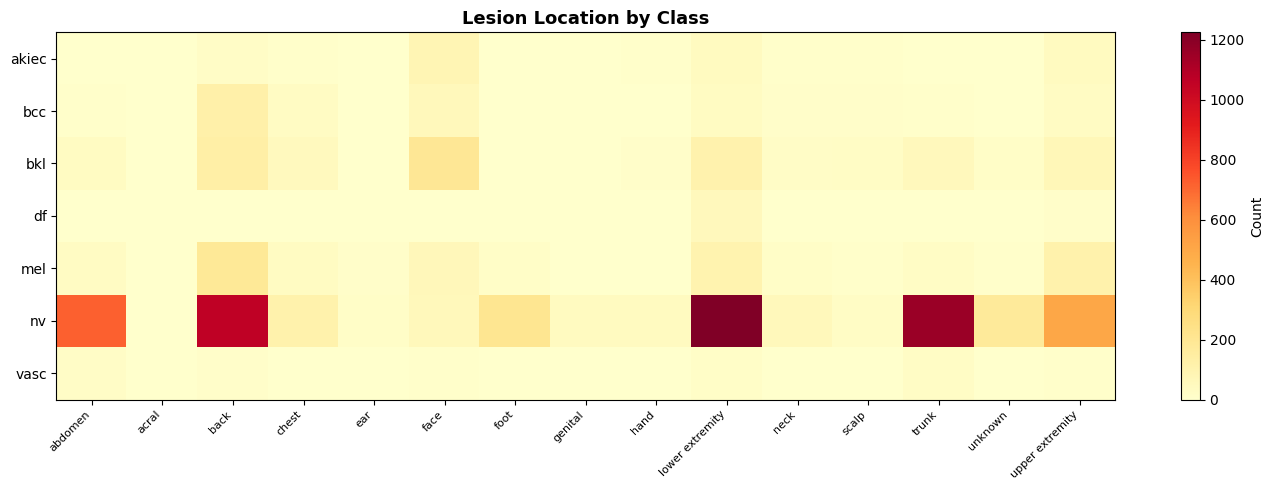

In [23]:
loc_counts = df.groupby(['dx', 'localization']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(loc_counts.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(loc_counts.index)))
ax.set_yticklabels(loc_counts.index)
ax.set_xticks(range(len(loc_counts.columns)))
ax.set_xticklabels(loc_counts.columns, rotation=45, ha='right', fontsize=8)
plt.colorbar(im, ax=ax, label='Count')
ax.set_title('Lesion Location by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 Diagnosis Confirmation Method

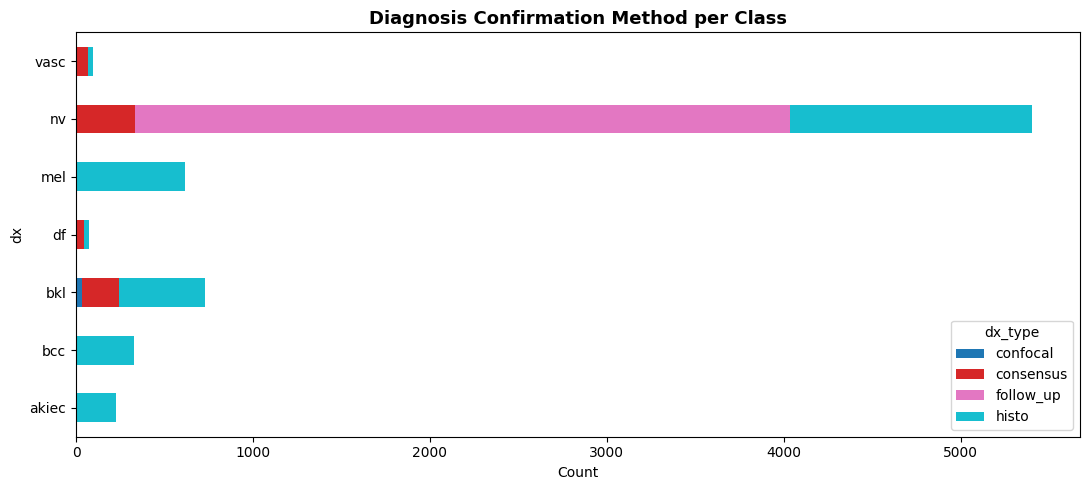

In [25]:
dx_type_counts = df.groupby(['dx', 'dx_type']).size().unstack(fill_value=0)
dx_type_counts.plot(kind='barh', stacked=True, figsize=(11, 5),
                     colormap='tab10')
plt.title('Diagnosis Confirmation Method per Class', fontsize=13, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### 4.7 Melanoma vs Nevi — Most Confused Pair

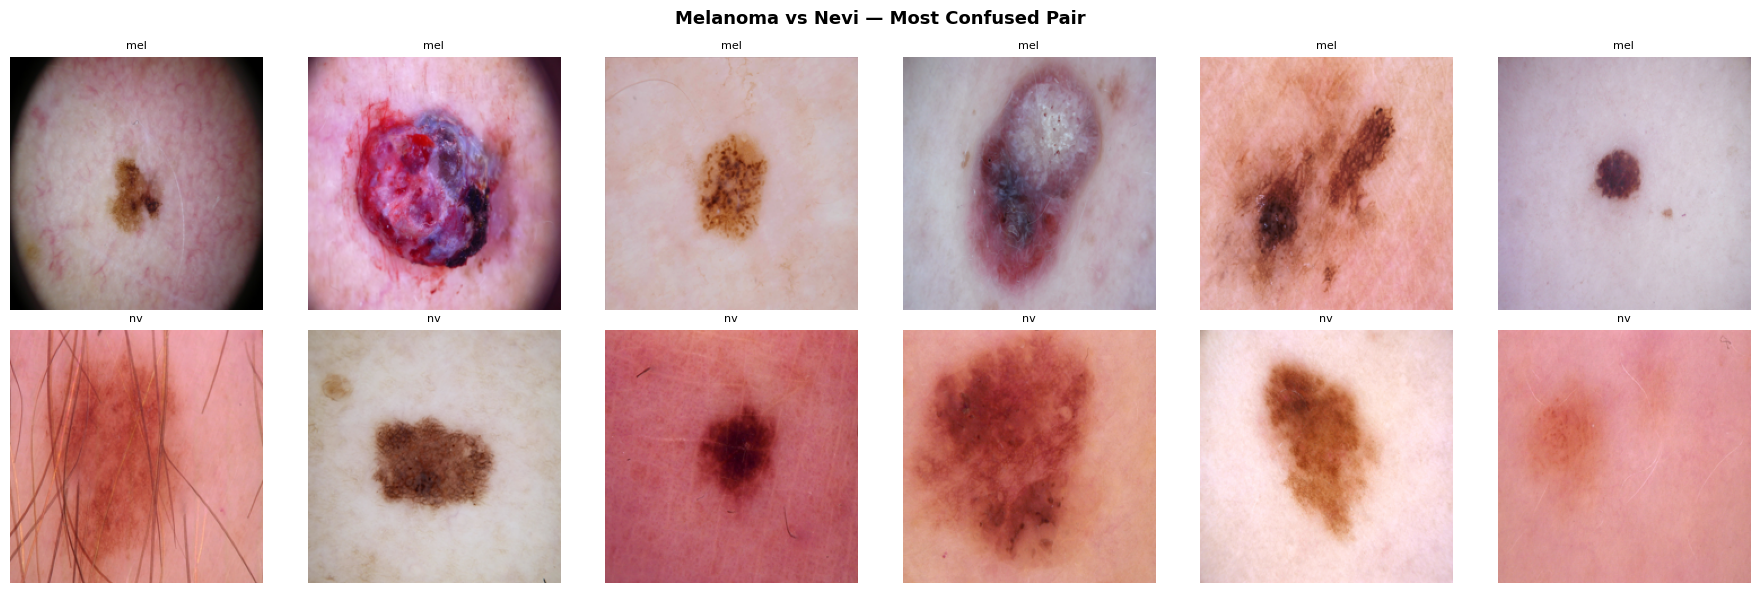

In [27]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for row, cls in enumerate(['mel', 'nv']):
    samples = df[df['dx'] == cls]['path'].sample(6, random_state=7).values
    for col, path in enumerate(samples):
        axes[row][col].imshow(Image.open(path).resize((224, 224)))
        axes[row][col].set_title(f'{cls}', fontsize=8)
        axes[row][col].axis('off')
axes[0][0].set_ylabel('Melanoma', fontsize=10, fontweight='bold', rotation=90, labelpad=5)
axes[1][0].set_ylabel('Nevi', fontsize=10, fontweight='bold', rotation=90, labelpad=5)
fig.suptitle('Melanoma vs Nevi — Most Confused Pair', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.8 Lesion Localization Overview

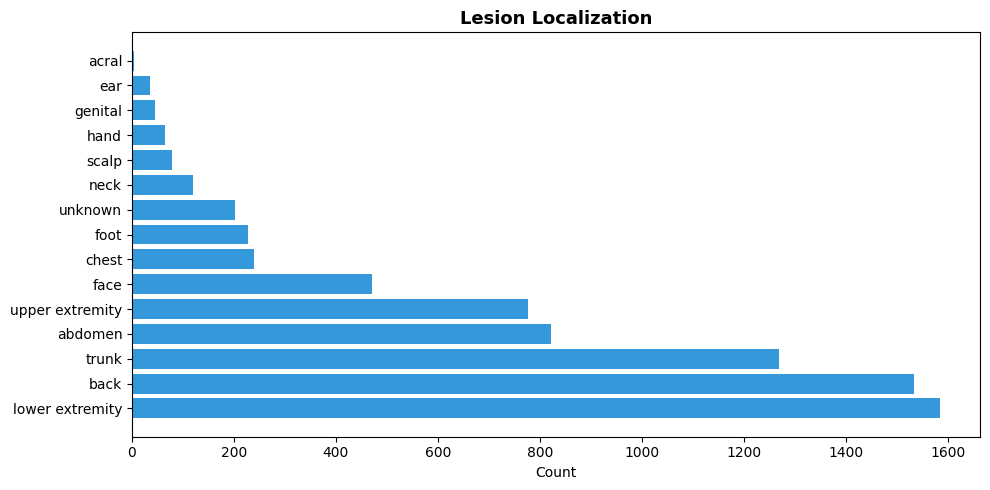

In [29]:
loc = df['localization'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(loc.index, loc.values, color='#3498db')
ax.set_title('Lesion Localization', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split

In [30]:
train_df, tmp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
val_df,  test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df['label'], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')

Train 5976 | Val 747 | Test 747


## 6. Dataset, Transforms & Data Loaders

In [31]:
# HAM10000-specific stats
mean = [0.7630, 0.5456, 0.5700]
std  = [0.1409, 0.1526, 0.1695]

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class SkinDataset(Dataset):
    def __init__(self, df, tfm):
        self.paths  = df['path'].tolist()
        self.labels = df['label'].tolist()
        self.tfm    = tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tfm(Image.open(self.paths[i]).convert('RGB')), self.labels[i]

# WeightedRandomSampler — caps dominance of 'nv' class
counts    = np.bincount(train_df['label'].values, minlength=len(CLASS_NAMES)).astype(float)
# Soft weighting: sqrt dampens extreme ratios so val dist isn't totally alien
w_class   = 1.0 / np.sqrt(counts + 1)
w_sample  = w_class[train_df['label'].values]
sampler   = WeightedRandomSampler(w_sample, num_samples=len(w_sample), replacement=True)

train_ds = SkinDataset(train_df, train_tfm)
val_ds   = SkinDataset(val_df,   eval_tfm)
test_ds  = SkinDataset(test_df,  eval_tfm)

train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)